In [8]:
import pandas as pd
import numpy as np

data_df = pd.read_csv('Advertising.csv', index_col=0)

In [9]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [10]:
# Extracting Features (X) and Target (y)

x = data_df[['TV','radio']].to_numpy()
y = data_df[['sales']].to_numpy()

- x is the feature matrix containing two advertising channels: TV and radio budgets.
- y is the target vector — the sales values we want to predict.
- .to_numpy() converts the DataFrame columns to raw NumPy arrays for math operations.

In [11]:
# Adding the Bias Column (Ones)
x = np.concat((np.ones((x.shape[0], 1)), x), axis = 1)

- This adds a column of 1s to the left of x.
- This is needed so the mathematical formula can include a bias/intercept term (β₀) — the baseline sales when all ad spend is zero.
- After this, x has shape (n, 3): [1, TV, radio] for every row.

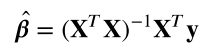

In [12]:
#  Manual Multiple Linear Regression (Normal Equation)
first_term = np.linalg.inv(np.dot(x.T,x))
betas = first_term.dot(x.T).dot(y)

- x.T is the transpose of x.
- np.dot(x.T, x) computes XᵀX.
- np.linalg.inv(...) computes the matrix inverse — (XᵀX)⁻¹.
- The full expression computes β = (XᵀX)⁻¹ Xᵀ y, giving the optimal regression coefficients [β₀, β₁, β₂].
- This is the from-scratch implementation without using scikit-learn.

In [13]:
# Printing the Betas
beta = betas.flatten()
beta

array([2.92109991, 0.04575482, 0.18799423])

In [ ]:
# Print the regression equation in readable form
print(f'y = {beta[0]:.3f} + {beta[1]:.3f} x1 + {beta[2]:.3f} x2')

y = 2.921 + 0.046 x1 + 0.188 x2


In [ ]:
# mporting scikit-learn Tools
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

sse = lambda y_true, y_prod : np.sum(np.power((y_true, y_prod), 2))

- LinearRegression — scikit-learn's built-in regression model.
- StandardScaler — for normalizing features (imported but not used here).
- train_test_split — splits data into training and testing sets.
- mean_absolute_error, mean_squared_error, r2_score — evaluation metrics.
- The sse lambda at the end has a bug: np.power((y_true, y_prod), 2) should be np.power(y_true - y_prod, 2). It's also not - used later (SSE is recomputed manually below).

In [16]:
x = data_df[['TV','radio']].to_numpy()
y = data_df[['sales']].to_numpy()

In [ ]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 999)

- Splits the dataset: 80% for training, 20% for testing.
- random_state=999 ensures the split is reproducible — you get the same split every time.

In [ ]:
# Training the Model
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- Creates a LinearRegression object.
- .fit(...) trains the model on the training data — it internally computes the optimal coefficients using the Normal Equation (similar to what we did manually above).

In [ ]:
# Making Predictions
y_predict = lin_reg.predict(x_test)

Uses the trained model to predict sales for the unseen test data (x_test).

In [ ]:
# Sum of Squared Errors (SSE)
sse = np.sum(np.power((y_test - y_predict), 2))
print('Sum of Squared Error = ', sse.round(4))

Sum of Squared Error =  106.5115


- Computes SSE = Σ(actual − predicted)².
- Measures total prediction error. Lower is better, but it's scale-dependent (harder to compare across datasets).

In [ ]:
# Mean Squared Error (MSE)
print('Mean Squared Error = ', mean_squared_error(y_test, y_predict))

Mean Squared Error =  2.6627875158200003


MSE = SSE / n. Averages the squared errors. Penalizes large errors heavily due to squaring.

In [ ]:
# Mean Absolute Error (MAE)
print('Mean Absolute Error = ', mean_absolute_error(y_test, y_predict))

Mean Absolute Error =  1.268229950045677


MAE = Σ|actual − predicted| / n. More interpretable than MSE — tells you the average prediction error in the original units (e.g., sales units).

In [23]:
print('R2 Coefficient = ', r2_score(y_test, y_predict))

R2 Coefficient =  0.8948652390616871


R² = 1 − RSS/TSS. Measures how much of the variance in sales is explained by the model. Ranges from 0 to 1 (higher = better).

### Problem with this R2 Coefficient

A higher R
2
 may look like a better model even when the new features are meaningless.

This can cause:

Overfitting
More complex models
Poor performance on new data

That is why Adjusted R
2
 is often preferred, because it penalizes unnecessary features.

### Adjusted R2 Coefficient

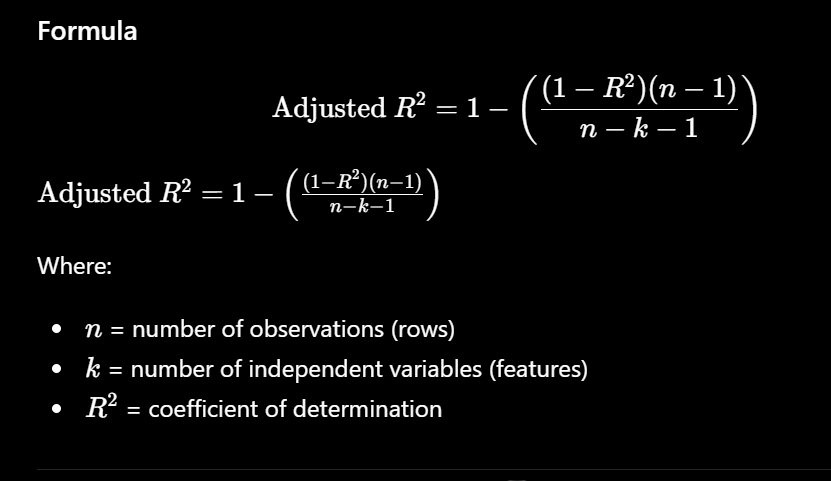

## The Core Problem

R² has a major weakness:

> It almost never decreases when new predictors are added.

Even completely useless variables can slightly increase R².

This creates a misleading impression that the model is improving.


### Why Does R² Increase?

Recall:

$R^2 = 1 - \frac{RSS}{TSS}$

Where:

* (RSS) = unexplained error
* (TSS) = total variation

When a new variable is added:

* The regression model gains extra flexibility.
* It can fit the training data more closely.
* Therefore residual error ((RSS)) usually decreases.

Since:

$R^2 = 1 - \frac{smaller\ number}{same\ number}$

R² increases.


### Why is This Dangerous?

Suppose we are predicting salary.

### Useful Features

* Years of experience
* Education level
* Skill score

Model:

* R² = 0.81


Now add:

### Random Features

* Favorite movie
* Shoe size
* Lucky number

New Model:

* R² = 0.814

The increase happens because:

* The model memorizes small random patterns.
* More variables make the model more flexible.
* Training fit improves slightly.

But:

* Real predictive power may not improve.
* Future prediction may become worse.
* Model becomes unnecessarily complex.

This problem is called:

#### Overfitting


### The Main Idea Behind Adjusted R²

Adjusted R² asks an important question:

> "Did the new variable improve the model enough to justify its complexity?"

Instead of blindly rewarding additional variables, it introduces a penalty.

Regular R² only rewards:

* Better fit

Adjusted R² balances two things:

| Goal            | Effect  |
| --------------- | ------- |
| Better fit      | Reward  |
| More predictors | Penalty |

So:

* Useful variables → Adjusted R² increases
* Useless variables → Adjusted R² decreases


Adjusted R² modifies R² by penalizing unnecessary predictors.

It increases only if:

> The new variable improves the model more than expected by chance.


## Formula

$Adjusted\ R^2 = 1 - (1 - R^2)\frac{n-1}{n-d-1} $

Where:

| Symbol | Meaning                |
| ------ | ---------------------- |
| (R^2)  | Regular R²             |
| (n)    | Number of observations (rows) |
| (d)    | Number of predictors (columns)   |


### Core Idea

Adjusted R² introduces a penalty factor:

$\frac{n-1}{n-p-1}$

As the number of predictors (p) increases:

* Denominator becomes smaller
* Penalty becomes larger

Therefore:

* Irrelevant variables may reduce Adjusted R².
* Useful variables increase Adjusted R².

### Can Adjusted R² Be Negative?

Yes.

This happens when:

* The model performs very poorly.
* Predictors explain almost nothing.

A negative Adjusted R² means:

> The model is worse than simply predicting the mean.


In [ ]:
#  Adjusted R² Function
from sklearn.metrics import r2_score

def adj_r2(y_true, y_predict, d= 3):
    r2score = r2_score(y_true, y_predict)
    
    n = len(y_true)
    
    return 1 - (1- r2score) * ((n-1) / (n-d-1))

A custom function implementing the Adjusted R² formula. d is the number of predictors (features).

In [25]:
print("Adjusted R2 Score : " , adj_r2(y_test, y_predict, d= x_test.shape[-1]))

print("R2 coeff = ", r2_score(y_test, y_predict))

Adjusted R2 Score :  0.8891822790109676
R2 coeff =  0.8948652390616871


- x_test.shape[-1] automatically gets the number of features (2 here: TV and radio).
- Prints both scores side by side so you can compare. If they're similar, the features are genuinely useful.

<Figure size 1000x700 with 0 Axes>

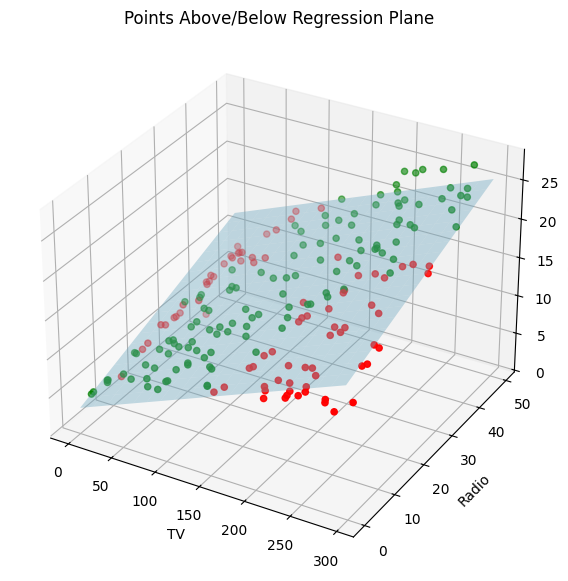

In [ ]:
# 3D Visualization

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Example data
TV = x[:,0]
radio = x[:,1]
Sales = y.flatten()

# Example predicted values
y_pred = lin_reg.predict(x).flatten()

# Create figure
fig = plt.figure(figsize=(10, 7))

# Example regression coefficients
# Sales = b0 + b1*TV + b2*radio
b0 = lin_reg.intercept_[0]
b1, b2 = lin_reg.coef_[0]

# Assign colors
colors = np.where(Sales > y_pred, 'green', 'red')

# Create figure
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with conditional colors
ax.scatter(
    TV,
    radio,
    Sales,
    c=colors,
    s=20
)

# Create plane mesh
tv_grid, radio_grid = np.meshgrid(
    np.linspace(TV.min(), TV.max(), 20),
    np.linspace(radio.min(), radio.max(), 20)
)

# Plane equation
sales_plane = b0 + b1 * tv_grid + b2 * radio_grid

# Plot regression plane
ax.plot_surface(
    tv_grid,
    radio_grid,
    sales_plane,
    alpha=0.4,
    color='skyblue'
)

# Labels
ax.set_xlabel("TV")
ax.set_ylabel("Radio")
ax.set_zlabel("Sales")

ax.set_title("Points Above/Below Regression Plane")

plt.show()

This is the most visual cell. It:

- Plots actual data points in 3D space (axes: TV, Radio, Sales).
- Colors each point: 🟢 green if actual sales > predicted, 🔴 red if actual < predicted.
- Draws the regression plane — the flat surface the model uses to make predictions.
- Labels axes and titles the chart: "Points Above/Below Regression Plane".

This gives an intuitive visual of how well the regression plane fits the actual data cloud.